### Phase 1: Data Loading & Exploratory Data Analysis
We load the campaign data and check for data leakage (users exposed to both groups) before calculating our baseline conversion rates.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
%matplotlib inline

In [2]:
# Load data
df = pd.read_csv("../data/marketing_data.csv" , index_col=0)

# Display first rows
df.head()

,user id,test group,converted,total ads,most ads day,most ads hour
0,1069124,ad,False,130,Monday,20
1,1119715,ad,False,93,Tuesday,22
2,1144181,ad,False,21,Tuesday,18
3,1435133,ad,False,355,Tuesday,10
4,1015700,ad,False,276,Friday,14


In [3]:
# Shape and info
print("Shape:", df.shape)
print(df.info())

# Summary stats for numeric columns
df.describe().T

Shape: (588101, 6)
<class 'pandas.core.frame.DataFrame'>
Index: 588101 entries, 0 to 588100
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   user id        588101 non-null  int64 
 1   test group     588101 non-null  object
 2   converted      588101 non-null  bool  
 3   total ads      588101 non-null  int64 
 4   most ads day   588101 non-null  object
 5   most ads hour  588101 non-null  int64 
dtypes: bool(1), int64(3), object(2)
memory usage: 27.5+ MB
None


,count,mean,std,min,25%,50%,75%,max
user id,588101.0,1.310692e+06,202225.983128,900000.0,1143190.0,1313725.0,1484088.0,1654483.0
total ads,588101.0,2.482088e+01,43.715181,1.0,4.0,13.0,27.0,2065.0
most ads hour,588101.0,1.446906e+01,4.834634,0.0,11.0,14.0,18.0,23.0


In [4]:
# Convert boolean to integer for numerical tests
df['converted'] = df['converted'].astype(int)

df.dtypes

user id           int64
test group       object
converted         int64
total ads         int64
most ads day     object
most ads hour     int64
dtype: object

In [5]:
# Missing value checking
print("\nNull value present?\n", df.isnull().any())

# DUplicate values checking
print("\nDuplicate value present?", df.duplicated().any())


Null value present?
 user id          False
test group       False
converted        False
total ads        False
most ads day     False
most ads hour    False
dtype: bool

Duplicate value present? False


In [6]:
# Unique values
print("Test group:", df['test group'].unique())
print("Most ads day:", df['most ads day'].unique())

Test group: ['ad' 'psa']
Most ads day: ['Monday' 'Tuesday' 'Friday' 'Saturday' 'Wednesday' 'Sunday' 'Thursday']


In [7]:
# Check if any user is in both groups
users_in_both = df.groupby('user id')['test group'].nunique()
contaminated_users = users_in_both[users_in_both > 1].count()
print(f"Users in both groups (Contaminated): {contaminated_users}")

Users in both groups (Contaminated): 0


#### 1.1 Visualizing the Baseline


In a real-world scenario, the control group (PSA) is usually much smaller than the treatment group (Ad) to avoid wasting ad spend on non-revenue generating PSAs.

In [8]:
# Calculate basic metrics
summary = df.groupby('test group').agg(
    users=('user id', 'count'),
    conversions=('converted', 'sum'),
    avg_ads_seen=('total ads', 'mean')
)
summary['conversion_rate (%)'] = (summary['conversions'] / summary['users']) * 100

display(summary)

,users,conversions,avg_ads_seen,conversion_rate (%)
test group,,,,
ad,564577,14423,24.823365,2.554656
psa,23524,420,24.761138,1.785411


C:\Users\HP\AppData\Local\Temp\ipykernel_21600\3308836224.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='test group', ax=axes[0], palette='Set2')
C:\Users\HP\AppData\Local\Temp\ipykernel_21600\3308836224.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary.reset_index(), x='test group', y='conversion_rate (%)', ax=axes[1], palette='Set2')


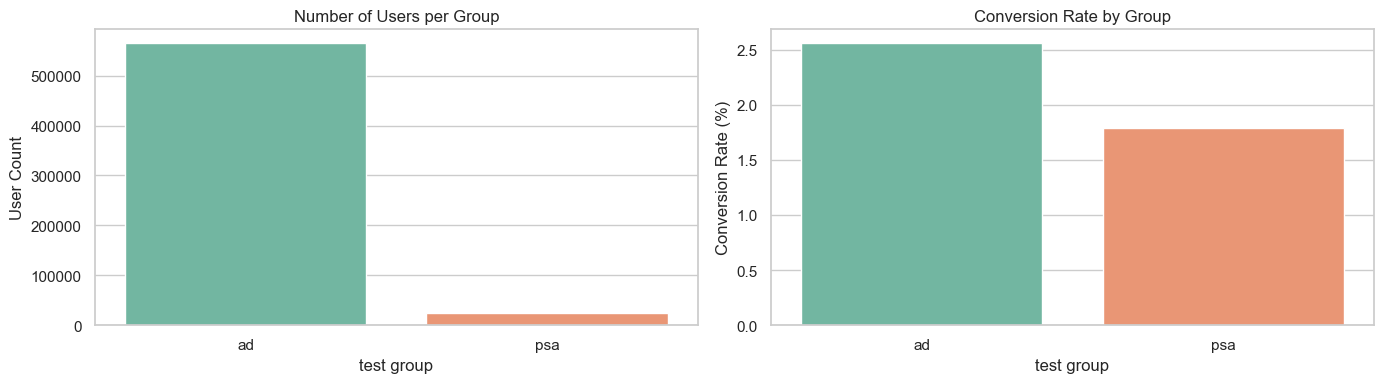

In [9]:
# Plotting the test group sizes and conversion rates
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Plot 1: Group Sizes
sns.countplot(data=df, x='test group', ax=axes[0], palette='Set2')
axes[0].set_title('Number of Users per Group')
axes[0].set_ylabel('User Count')

# Plot 2: Conversion Rates
sns.barplot(data=summary.reset_index(), x='test group', y='conversion_rate (%)', ax=axes[1], palette='Set2')
axes[1].set_title('Conversion Rate by Group')
axes[1].set_ylabel('Conversion Rate (%)')

plt.tight_layout()
plt.show()

In [10]:
# Conversion rate by weekday and sample
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
summary_by_weekdays = (
    df.groupby([df['most ads day'], df['test group']])['converted'].mean().unstack().reindex(weekday_order)) * 100

display(summary_by_weekdays)

test group,ad,psa
most ads day,,
Monday,3.324120,2.255854
Tuesday,3.044038,1.444788
Wednesday,2.535586,1.575931
Thursday,2.163714,2.023047
Friday,2.246495,1.630292
Saturday,2.130657,1.399580
Sunday,2.461983,2.059497


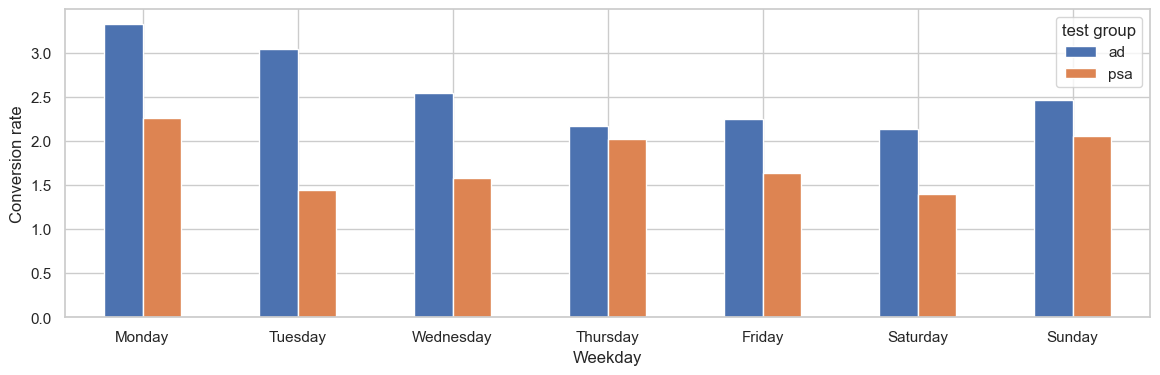

In [11]:
# Plotting conversion rate by weekday and sample
summary_by_weekdays.plot(kind='bar', figsize=(14, 4))
plt.xlabel('Weekday')
plt.ylabel('Conversion rate')
plt.xticks(rotation=0)
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_21600\2730360153.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=hour_count.index, y=hour_count.values, ax=axes[0], palette='Set1')
C:\Users\HP\AppData\Local\Temp\ipykernel_21600\2730360153.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary_by_hour, x='most ads hour', y='converted', ax=axes[1], palette='Set2')


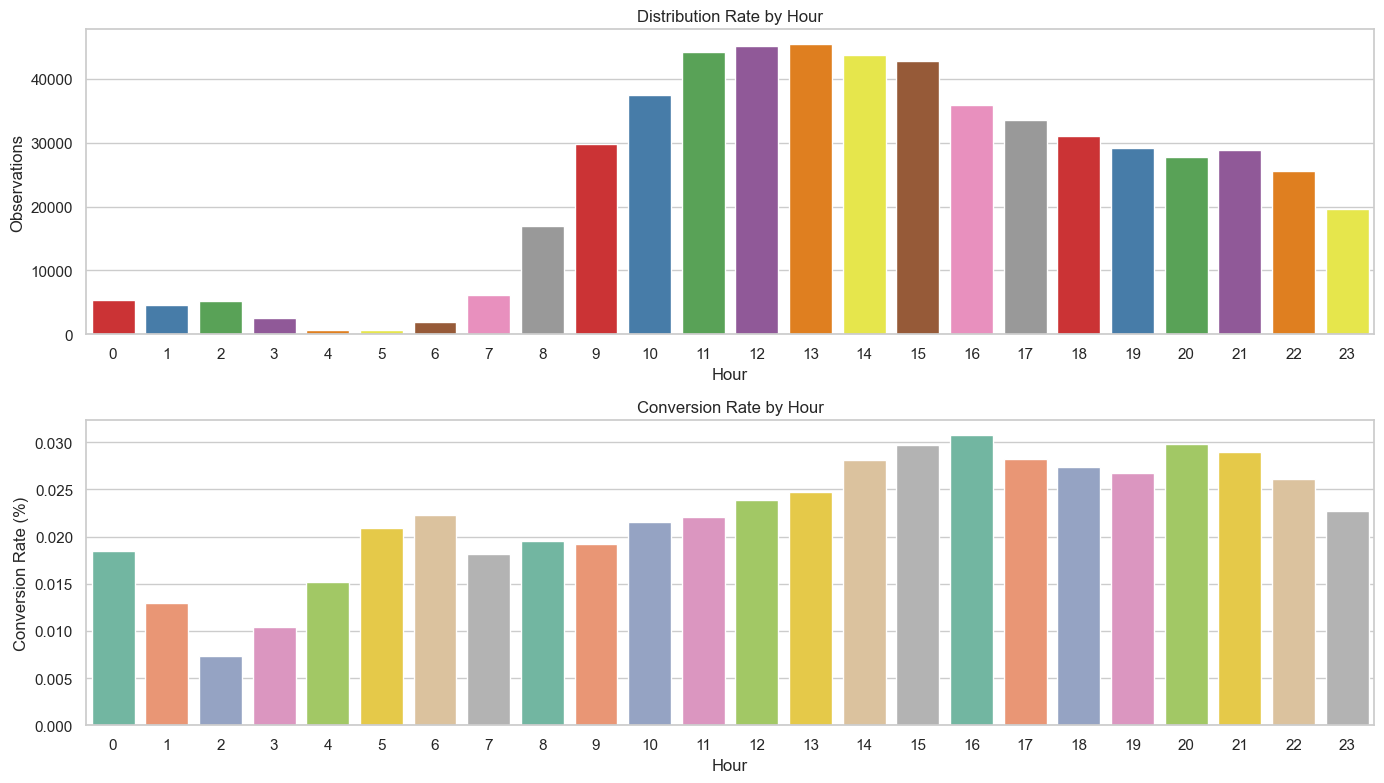

In [12]:
# Plotting conversion rate by hour and ad sample
hour_count = df[df['test group'] == 'ad']['most ads hour'].value_counts().sort_index()
summary_by_hour = df.groupby('most ads hour')['converted'].mean().reset_index()

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

sns.barplot(x=hour_count.index, y=hour_count.values, ax=axes[0], palette='Set1')
axes[0].set_title("Distribution Rate by Hour")
axes[0].set_xlabel("Hour")
axes[0].set_ylabel("Observations")

sns.barplot(data=summary_by_hour, x='most ads hour', y='converted', ax=axes[1], palette='Set2')
axes[1].set_title("Conversion Rate by Hour")
axes[1].set_xlabel("Hour")
axes[1].set_ylabel("Conversion Rate (%)")

plt.tight_layout()
plt.show()

In [13]:
# Conversion rate by hour and weekday (ad sample)
cr_hour_weekday_ad = (
    df[df['test group'] == 'ad']
        .groupby(['most ads day', 'most ads hour'])['converted']
        .mean()
        .unstack()
        .reindex(weekday_order)) * 100

display(cr_hour_weekday_ad)

most ads hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
most ads day,,,,,,,,,,,,,,,,,,,,,
Monday,1.707317,1.694915,0.705219,1.265823,0.000000,3.260870,4.198473,1.842105,3.399668,2.657503,...,4.487498,4.294479,3.737482,3.589838,2.778881,3.056867,3.240639,3.393025,2.999492,2.470588
Tuesday,1.963534,1.424051,0.549451,2.083333,2.000000,1.315789,2.262443,2.194787,1.824212,2.364865,...,3.610108,4.119519,4.557641,3.525955,3.617785,2.850212,2.708272,2.385839,3.448276,3.081232
Wednesday,1.190476,0.838926,0.484653,0.303030,2.000000,0.714286,1.396648,1.190476,1.661565,1.708108,...,2.978407,2.999651,3.574523,3.230272,2.749816,2.080123,2.583587,2.745449,2.532804,2.219140
Thursday,2.542373,1.881331,1.317716,0.550964,2.752294,2.197802,2.105263,1.592040,1.506245,1.589464,...,2.552346,2.458194,2.625385,2.145386,2.277481,2.418136,2.867666,2.084320,2.173913,1.992174
Friday,1.982652,1.057402,1.212121,0.388350,1.694915,1.550388,1.212121,1.866405,1.653944,2.008407,...,2.461492,2.646617,2.770234,2.148399,2.397190,2.068365,3.023516,2.919116,2.111041,1.709832
Saturday,2.359109,0.854701,0.444444,1.104972,0.000000,5.681818,5.158730,2.338377,2.325581,1.646091,...,2.017439,2.180951,1.991193,2.247423,2.564103,2.677165,2.416721,3.214443,2.535861,2.219091
Sunday,1.648352,1.754386,0.581395,1.902174,2.000000,1.587302,0.722022,2.020202,1.636848,1.633259,...,2.033510,2.269632,2.749396,3.151467,2.993763,3.561947,4.366461,3.670715,3.110048,2.961866


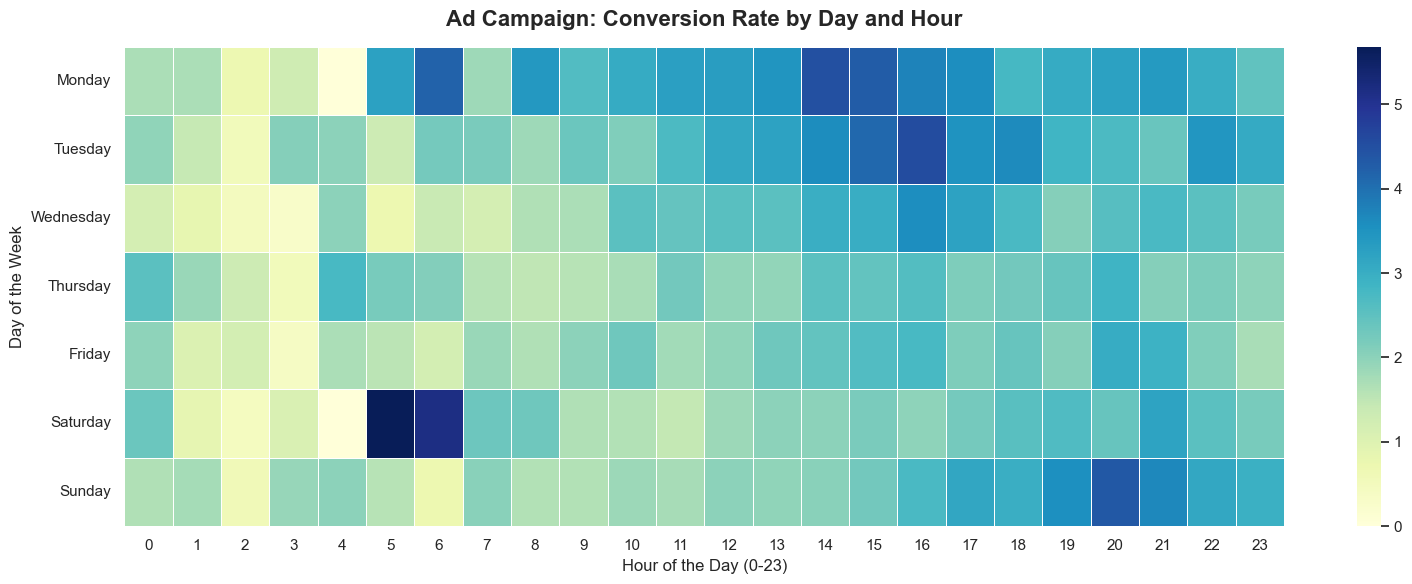

In [14]:
# Create the heatmap of conversion rate by hour and weekday (ad sample)
plt.figure(figsize=(16, 6))

sns.heatmap(
    cr_hour_weekday_ad, 
    cmap='YlGnBu',
    annot=False,
    linewidths=0.5,
)

plt.title('Ad Campaign: Conversion Rate by Day and Hour', fontsize=16, fontweight='bold', pad=15)
plt.ylabel('Day of the Week', fontsize=12)
plt.xlabel('Hour of the Day (0-23)', fontsize=12)
plt.yticks(rotation=0) 

plt.tight_layout()
plt.show()